In [28]:
# ==============================================================================
# 1. SETUP & LIBRARIES
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.optimize import linprog
import warnings

# Suppress warnings for clean output
warnings.filterwarnings('ignore')

# Set professional plot style
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.1)
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.family'] = 'sans-serif'

print("✅ Libraries Imported Successfully")

✅ Libraries Imported Successfully


In [29]:
# ==============================================================================
# 2. DATA LOADING & PREPROCESSING
# ==============================================================================
print("\n📂 Loading NHANES Datasets...")

# Load datasets
try:
    demo = pd.read_csv("demographic.csv")
    diet = pd.read_csv("diet.csv")
    exam = pd.read_csv("examination.csv")
    labs = pd.read_csv("labs.csv")
    quest = pd.read_csv("questionnaire.csv")
except FileNotFoundError:
    raise FileNotFoundError("Ensure all CSV files are in the same directory.")

# Merge datasets on SEQN (Participant ID)
# Using inner join to ensure we only analyze participants with complete data across all domains
df = demo.merge(diet, on="SEQN", how="inner") \
         .merge(exam, on="SEQN", how="inner") \
         .merge(labs, on="SEQN", how="inner") \
         .merge(quest, on="SEQN", how="inner")

print(f"📊 Merged Dataset Shape: {df.shape}")

# Select relevant features for clustering
# Demographics: Age, Gender, Income
# Diet: Calories, Protein, Carbs, Fat, Fiber, Sugar
# Health: BMI, Glucose, Cholesterol, Triglycerides
features_to_use = [
    'RIDAGEYR', 'RIAGENDR', 'INDFMPIR',       # Demographics
    'DR1TKCAL', 'DR1TPROT', 'DR1TCARB', 'DR1TTFAT', 'DR1TFIBE', 'DR1TSUGR', # Diet
    'BMXBMI',                                 # Body Measure
    'LBDSGLSI', 'LBXTC', 'LBXTR'              # Labs
]

# Filter to existing columns (in case some datasets vary)
available_features = [f for f in features_to_use if f in df.columns]
df_subset = df[available_features].copy()

# Handle Missing Values: Impute with Median (robust to outliers)
imputer = SimpleImputer(strategy='median')
df_imputed_array = imputer.fit_transform(df_subset)
df_imputed = pd.DataFrame(df_imputed_array, columns=available_features)

print(f"✅ Preprocessing Complete. Features used: {len(available_features)}")


📂 Loading NHANES Datasets...
📊 Merged Dataset Shape: (9813, 1812)
✅ Preprocessing Complete. Features used: 13



🔍 Determining Optimal Number of Clusters...


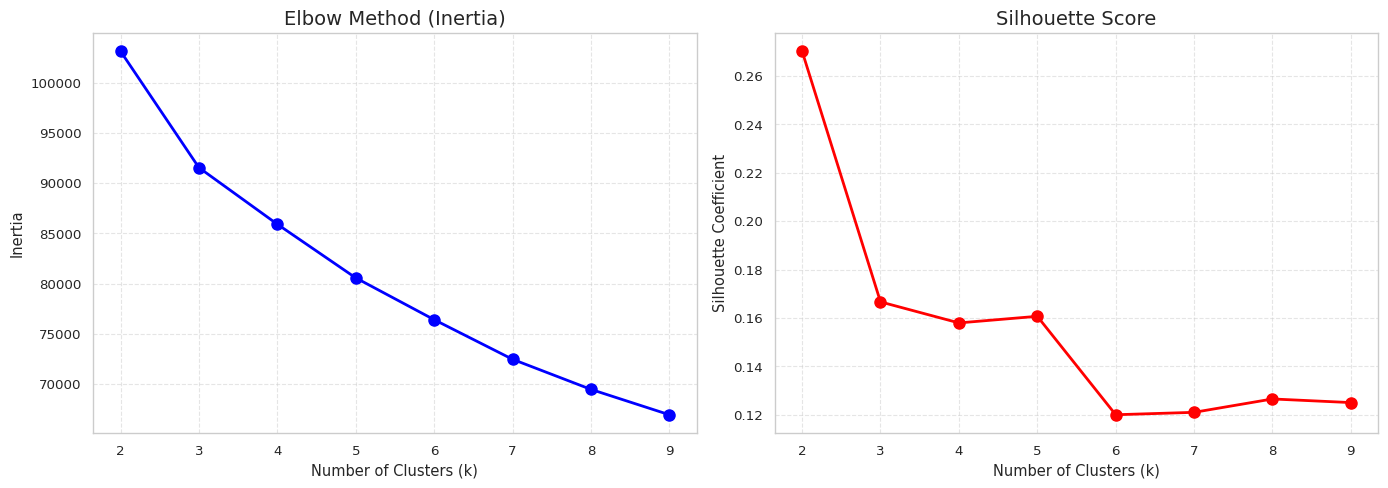

🏆 Optimal K Selected: 2 (Highest Silhouette Score: 0.270)


In [30]:
# ==============================================================================
# 3. CLUSTERING ANALYSIS (Determining Optimal K)
# ==============================================================================
print("\n🔍 Determining Optimal Number of Clusters...")

# Standardize data for clustering
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_imputed)

# Calculate Silhouette Scores for K=2 to K=9
k_range = range(2, 10)
sil_scores = []
inertias = []

for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_temp = kmeans_temp.fit_predict(df_scaled)
    sil_scores.append(silhouette_score(df_scaled, labels_temp))
    inertias.append(kmeans_temp.inertia_)

# Plot Elbow Method and Silhouette Score
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Plot
axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method (Inertia)', fontsize=14)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Silhouette Plot
axes[1].plot(k_range, sil_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score', fontsize=14)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Coefficient')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('clustering_validation.png', bbox_inches='tight')
plt.show()

# Select Best K based on highest Silhouette Score
best_k = k_range[np.argmax(sil_scores)]
print(f"🏆 Optimal K Selected: {best_k} (Highest Silhouette Score: {max(sil_scores):.3f})")


 Performing Final K-Means Clustering (k=2)...


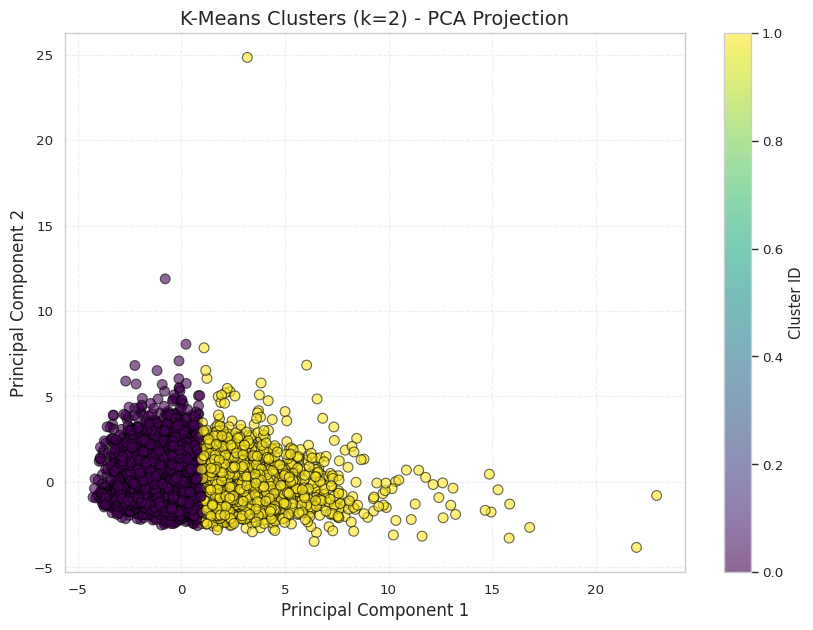

In [31]:
# ==============================================================================
# 4. FINAL CLUSTERING & VISUALIZATION
# ==============================================================================
print(f"\n Performing Final K-Means Clustering (k={best_k})...")

# Run final KMeans
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(df_scaled)

# Add cluster labels to the dataframe
df_imputed['Cluster'] = cluster_labels

# Visualize Clusters using PCA (2D Projection)
pca = PCA(n_components=2)
pca_data = pca.fit_transform(df_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(pca_data[:, 0], pca_data[:, 1], c=cluster_labels, cmap='viridis', alpha=0.6, edgecolors='k', s=50)
plt.title(f'K-Means Clusters (k={best_k}) - PCA Projection', fontsize=14)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.colorbar(scatter, label='Cluster ID')
plt.grid(True, linestyle='--', alpha=0.3)
plt.savefig('cluster_pca_visualization.png', bbox_inches='tight')
plt.show()


📊 Generating Cluster Profiles...

--- Cluster Nutritional & Health Profile (Means) ---
Cluster   Population_Avg        0        1
RIDAGEYR           31.63    30.07    36.68
RIAGENDR            1.51     1.57     1.30
INDFMPIR            2.21     2.16     2.35
DR1TKCAL         1942.26  1563.42  3168.57
DR1TPROT           73.43    59.72   117.82
DR1TCARB          240.20   195.36   385.33
DR1TTFAT           73.94    58.38   124.30
DR1TFIBE           14.99    12.20    24.04
DR1TSUGR          107.30    86.10   175.93
BMXBMI             25.60    25.12    27.16
LBDSGLSI            5.51     5.50     5.54
LBXTC             178.52   178.30   179.23
LBXTR              95.79    94.00   101.60


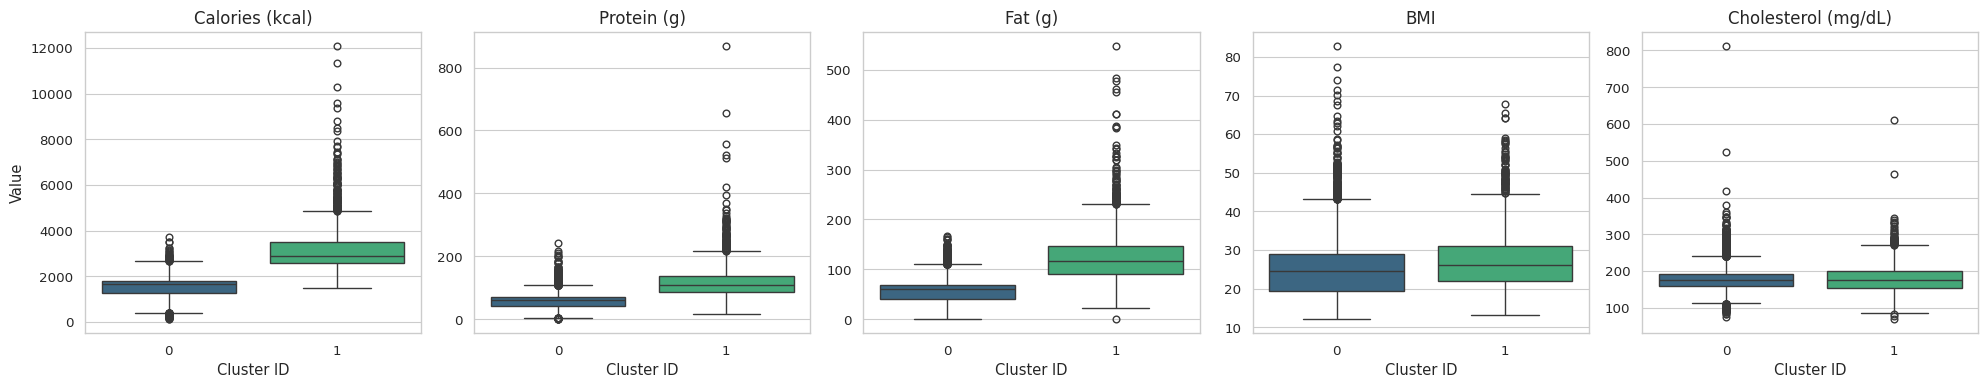

In [32]:
# ==============================================================================
# 5. CLUSTER PROFILING (Answering RQ1)
# ==============================================================================
print("\n📊 Generating Cluster Profiles...")

# Calculate mean values for each cluster
numeric_cols = [col for col in df_imputed.columns if col != 'Cluster']
cluster_profile = df_imputed.groupby('Cluster')[numeric_cols].mean().T

# Add Population Average for comparison
cluster_profile['Population_Avg'] = df_imputed[numeric_cols].mean()

# Reorder columns: Population Avg first, then clusters
cols_order = ['Population_Avg'] + list(range(best_k))
cluster_profile = cluster_profile.reindex(columns=cols_order)

# Display Profile Table
print("\n--- Cluster Nutritional & Health Profile (Means) ---")
print(cluster_profile.round(2).to_string())

# Visualize Key Metrics Across Clusters
key_metrics = ['DR1TKCAL', 'DR1TPROT', 'DR1TTFAT', 'BMXBMI', 'LBXTC']
metric_titles = ['Calories (kcal)', 'Protein (g)', 'Fat (g)', 'BMI', 'Cholesterol (mg/dL)']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, metric in enumerate(key_metrics):
    ax = axes[i]
    # Boxplot for distribution
    sns.boxplot(x='Cluster', y=metric, data=df_imputed, ax=ax, palette='viridis')
    ax.set_title(metric_titles[i], fontsize=12)
    ax.set_xlabel('Cluster ID')
    if i == 0: ax.set_ylabel('Value')
    else: ax.set_ylabel('')

plt.tight_layout()
plt.savefig('cluster_profiles_boxplots.png', bbox_inches='tight')
plt.show()

In [33]:
# ==============================================================================
# 6. DIET OPTIMIZATION MODEL (Answering RQ2 & RQ3)
# ==============================================================================
print("\n Running Linear Programming Diet Optimization...")

# Define Food Database (Nutrients per Unit/Serving)
foods = ['Brown Rice', 'Chicken Breast', 'Broccoli', 'Whole Milk', 'Salmon', 'Oats', 'Almonds']
nutrient_matrix = np.array([
    # Calories, Protein(g), Fat(g), Carbs(g), Fiber(g)
    [111, 2.6, 0.9, 23, 1.8],   # Brown Rice
    [165, 31, 3.6, 0, 0],       # Chicken Breast
    [34, 2.8, 0.4, 7, 2.6],     # Broccoli
    [42, 3.4, 1.0, 5, 0],       # Whole Milk
    [208, 20, 13, 0, 0],        # Salmon
    [389, 16.9, 6.9, 66, 10.6], # Oats
    [579, 21, 50, 22, 12.5]     # Almonds
])

# General Dietary Guidelines (for reference)
GUIDELINES = {'Calories': 2000, 'Protein': 50, 'Fat_Max': 70}

# Store optimization results
optimization_results = []

# Loop through each cluster to generate a personalized diet plan
for cluster_id in range(best_k):
    print(f"\n--- Optimizing for Cluster {cluster_id} ---")

    # Get target nutrients from cluster profile
    # We use the cluster's average current intake as the baseline target,
    # but aim to improve health metrics (e.g., reduce fat by 10%)

    target_cal = cluster_profile[cluster_id]['DR1TKCAL']
    target_prot = cluster_profile[cluster_id]['DR1TPROT']
    target_fat = cluster_profile[cluster_id]['DR1TTFAT'] * 0.9  # Aim for 10% fat reduction

    # Ensure minimum thresholds for safety
    target_cal = max(target_cal, 1200)
    target_prot = max(target_prot, 40)

    # --- Linear Programming Setup ---
    # Objective: Minimize total quantity (proxy for cost/volume)
    c_obj = np.ones(len(foods))

    # Constraints:
    # 1. Calories >= Target (allow 5% buffer below)
    # 2. Protein >= Target
    # 3. Fat <= Target Max
    A_ub = [
        -nutrient_matrix[:, 0],  # -Calories <= -Min_Cal
        nutrient_matrix[:, 2],   # Fat <= Max_Fat
        -nutrient_matrix[:, 1]   # -Protein <= -Min_Prot
    ]

    b_ub = [
        -(target_cal * 0.95),
        target_fat,
        -target_prot
    ]

    bounds = [(0, 10) for _ in foods]  # Max 10 servings per food

    # Solve
    res = linprog(c_obj, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')

    if res.success:
        optimized_quantities = res.x

        # Calculate actual nutrient totals from the optimized plan
        opt_cal = np.dot(optimized_quantities, nutrient_matrix[:, 0])
        opt_prot = np.dot(optimized_quantities, nutrient_matrix[:, 1])
        opt_fat = np.dot(optimized_quantities, nutrient_matrix[:, 2])

        # Store results
        optimization_results.append({
            'Cluster': cluster_id,
            'Target_Cal': target_cal, 'Opt_Cal': opt_cal,
            'Target_Prot': target_prot, 'Opt_Prot': opt_prot,
            'Target_Fat': target_fat, 'Opt_Fat': opt_fat,
            'Plan_Quantities': optimized_quantities
        })

        print(f"✅ Success! Cal: {opt_cal:.0f}, Prot: {opt_prot:.1f}, Fat: {opt_fat:.1f}")
    else:
        print(f" Optimization failed for Cluster {cluster_id}: {res.message}")
        optimization_results.append(None)



 Running Linear Programming Diet Optimization...

--- Optimizing for Cluster 0 ---
✅ Success! Cal: 1485, Prot: 61.8, Fat: 52.5

--- Optimizing for Cluster 1 ---
✅ Success! Cal: 3010, Prot: 124.7, Fat: 111.9



📈 Generating Comparison Charts...


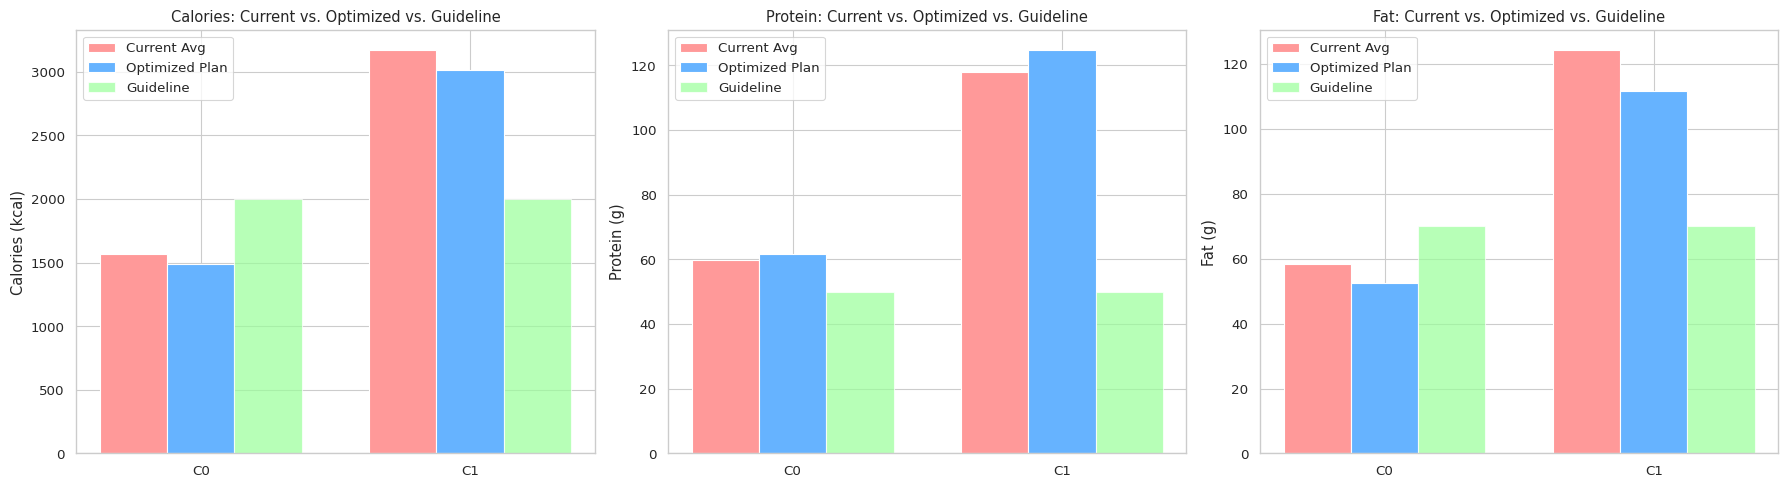

In [34]:
# ==============================================================================
# 7. EVALUATION & COMPARISON VISUALIZATIONS
# ==============================================================================
print("\n📈 Generating Comparison Charts...")

# Prepare data for plotting
clusters_plot = []
current_cals, opt_cals, guide_cals = [], [], []
current_prots, opt_prots, guide_prots = [], [], []
current_fats, opt_fats, guide_fats = [], [], []

for res in optimization_results:
    if res:
        cid = res['Cluster']
        clusters_plot.append(f"C{cid}")

        # Current Intake (from profile)
        curr_cal = cluster_profile[cid]['DR1TKCAL']
        curr_prot = cluster_profile[cid]['DR1TPROT']
        curr_fat = cluster_profile[cid]['DR1TTFAT']

        current_cals.append(curr_cal)
        current_prots.append(curr_prot)
        current_fats.append(curr_fat)

        # Optimized Intake
        opt_cals.append(res['Opt_Cal'])
        opt_prots.append(res['Opt_Prot'])
        opt_fats.append(res['Opt_Fat'])

        # Guidelines
        guide_cals.append(GUIDELINES['Calories'])
        guide_prots.append(GUIDELINES['Protein'])
        guide_fats.append(GUIDELINES['Fat_Max'])

x_pos = np.arange(len(clusters_plot))
width = 0.25

# Plot 1: Calories Comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
bars1 = ax.bar(x_pos - width, current_cals, width, label='Current Avg', color='#ff9999')
bars2 = ax.bar(x_pos, opt_cals, width, label='Optimized Plan', color='#66b3ff')
bars3 = ax.bar(x_pos + width, guide_cals, width, label='Guideline', color='#99ff99', alpha=0.7)
ax.set_ylabel('Calories (kcal)')
ax.set_title('Calories: Current vs. Optimized vs. Guideline')
ax.set_xticks(x_pos)
ax.set_xticklabels(clusters_plot)
ax.legend()

# Plot 2: Protein Comparison
ax = axes[1]
bars1 = ax.bar(x_pos - width, current_prots, width, label='Current Avg', color='#ff9999')
bars2 = ax.bar(x_pos, opt_prots, width, label='Optimized Plan', color='#66b3ff')
bars3 = ax.bar(x_pos + width, guide_prots, width, label='Guideline', color='#99ff99', alpha=0.7)
ax.set_ylabel('Protein (g)')
ax.set_title('Protein: Current vs. Optimized vs. Guideline')
ax.set_xticks(x_pos)
ax.set_xticklabels(clusters_plot)
ax.legend()

# Plot 3: Fat Comparison
ax = axes[2]
bars1 = ax.bar(x_pos - width, current_fats, width, label='Current Avg', color='#ff9999')
bars2 = ax.bar(x_pos, opt_fats, width, label='Optimized Plan', color='#66b3ff')
bars3 = ax.bar(x_pos + width, guide_fats, width, label='Guideline', color='#99ff99', alpha=0.7)
ax.set_ylabel('Fat (g)')
ax.set_title('Fat: Current vs. Optimized vs. Guideline')
ax.set_xticks(x_pos)
ax.set_xticklabels(clusters_plot)
ax.legend()

plt.tight_layout()
plt.savefig('optimization_impact_comparison.png', bbox_inches='tight')
plt.show()

In [35]:
# ==============================================================================
# 8. FINAL SUMMARY TABLE FOR REPORT
# ==============================================================================
print("\n📋 Final Optimization Summary Table:")

summary_data = []
for res in optimization_results:
    if res:
        cid = res['Cluster']
        curr_cal = cluster_profile[cid]['DR1TKCAL']
        curr_prot = cluster_profile[cid]['DR1TPROT']
        curr_fat = cluster_profile[cid]['DR1TTFAT']

        summary_data.append({
            'Cluster': f"Cluster {cid}",
            'Curr_Cal': curr_cal, 'Opt_Cal': res['Opt_Cal'], 'Delta_Cal': res['Opt_Cal'] - curr_cal,
            'Curr_Prot': curr_prot, 'Opt_Prot': res['Opt_Prot'], 'Delta_Prot': res['Opt_Prot'] - curr_prot,
            'Curr_Fat': curr_fat, 'Opt_Fat': res['Opt_Fat'], 'Delta_Fat': res['Opt_Fat'] - curr_fat
        })

summary_df = pd.DataFrame(summary_data)
print(summary_df.round(2).to_string(index=False))


📋 Final Optimization Summary Table:
  Cluster  Curr_Cal  Opt_Cal  Delta_Cal  Curr_Prot  Opt_Prot  Delta_Prot  Curr_Fat  Opt_Fat  Delta_Fat
Cluster 0   1563.42  1485.25     -78.17      59.72     61.79        2.07     58.38    52.54      -5.84
Cluster 1   3168.57  3010.14    -158.43     117.82    124.66        6.84    124.30   111.87     -12.43

✅ Analysis Complete. All plots saved to disk.
